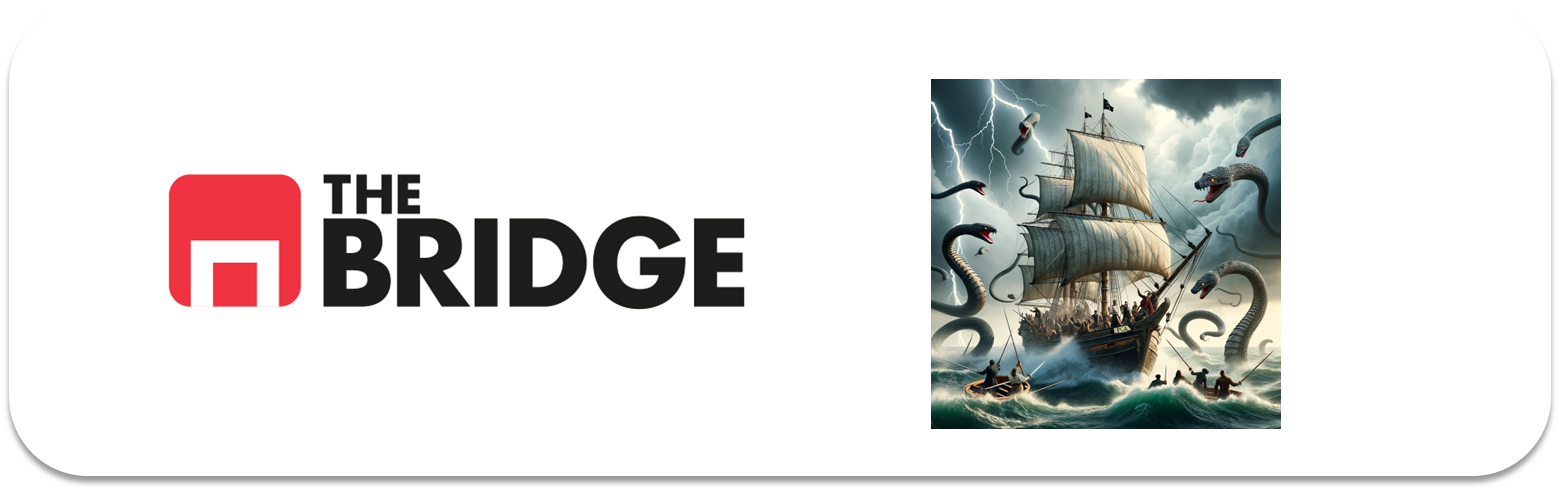

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import bootcampviztools as bt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df_sd2y = pd.read_csv("./data/credit_npo.csv")

In [3]:
df = df_sd2y.copy()

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [5]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [6]:
df = df.dropna(axis=0)

In [7]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df["SeriousDlqin2yrs"])

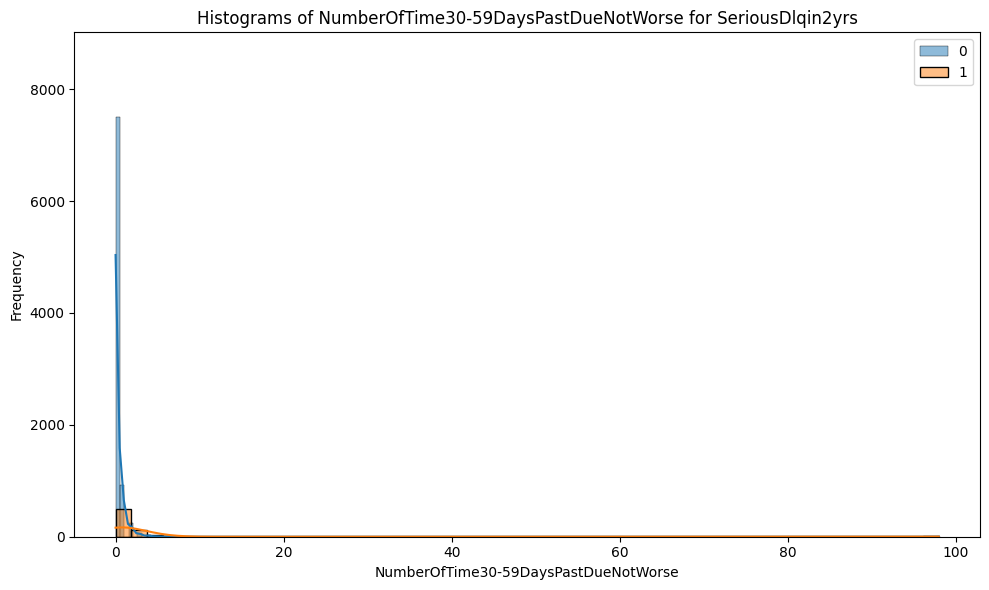

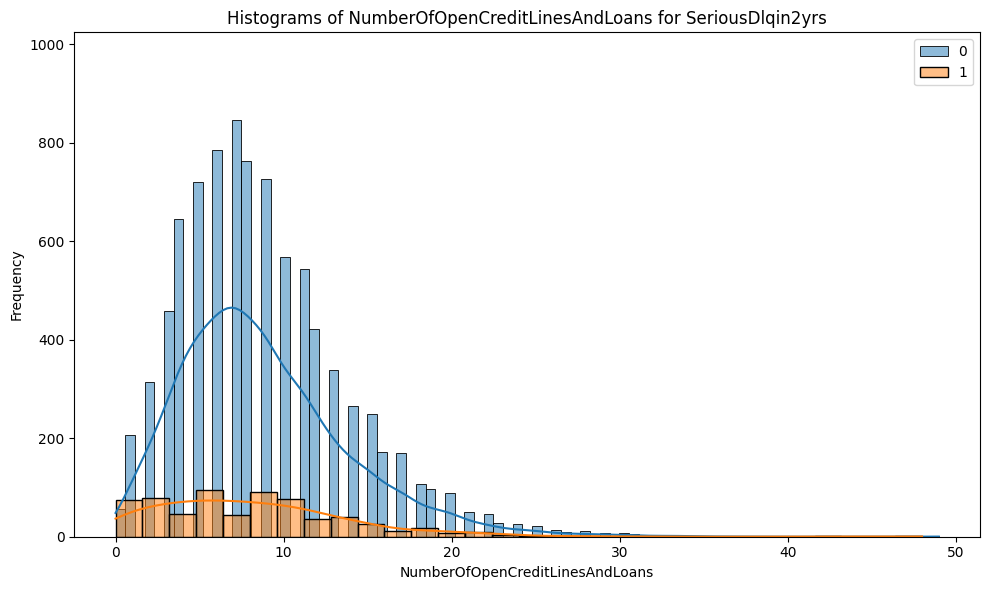

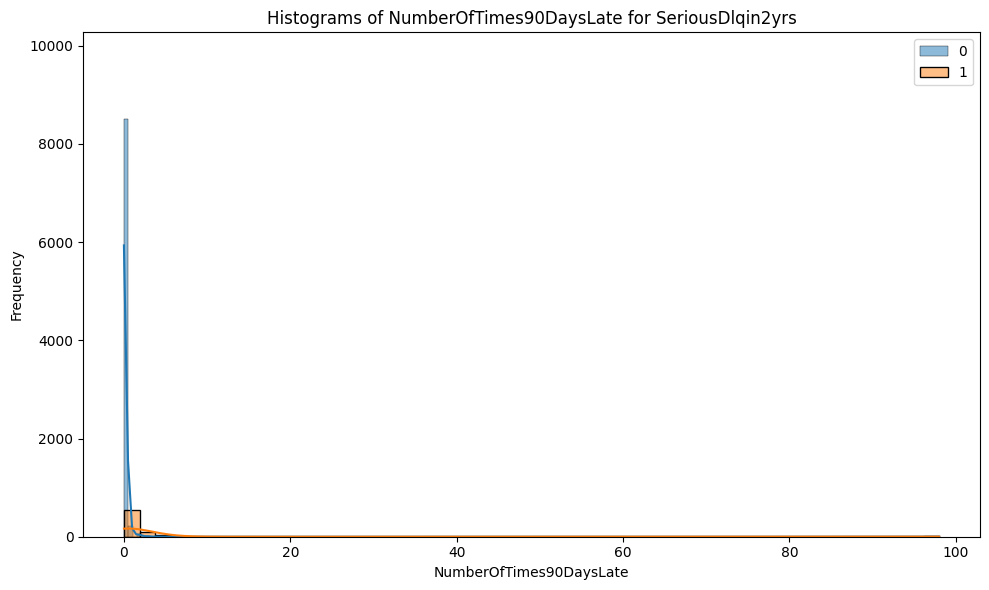

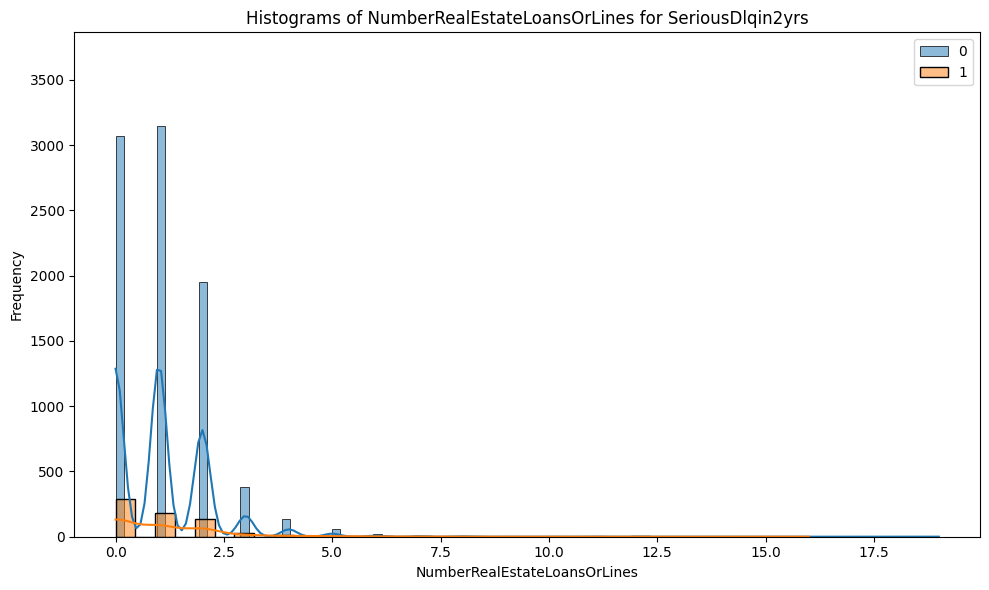

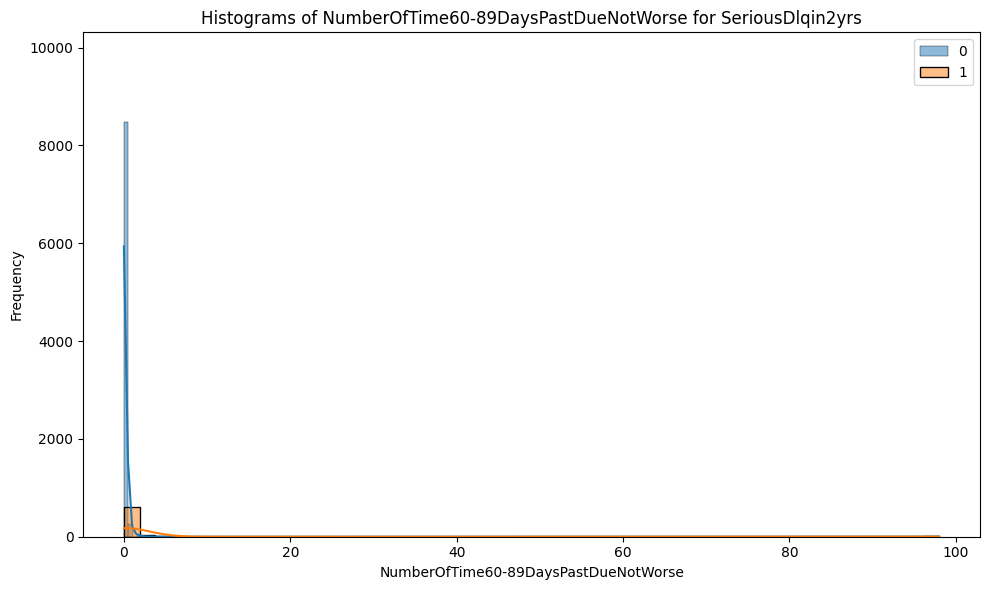

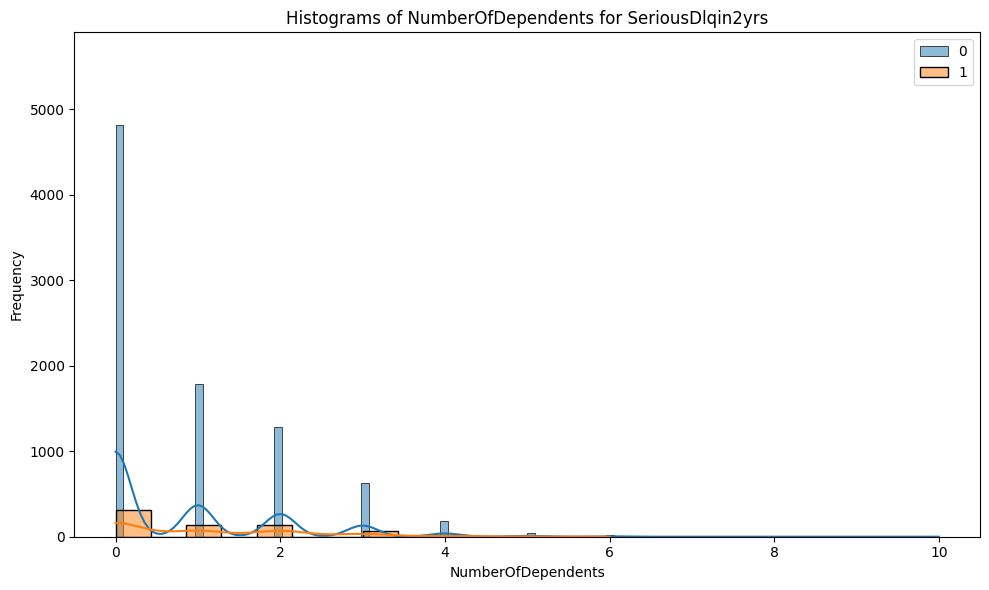

In [8]:
cols_to_reduce = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate", "NumberRealEstateLoansOrLines", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents"]


for col in cols_to_reduce:
    bt.plot_grouped_histograms(train_set, "SeriousDlqin2yrs", col)

In [9]:
train_set["NumberRealEstateLoansOrLines"].value_counts()

NumberRealEstateLoansOrLines
0     3361
1     3328
2     2084
3      410
4      149
5       65
6       22
7       11
8        7
11       4
9        3
10       2
12       2
16       2
13       1
19       1
Name: count, dtype: int64

Esta variable la dividiremos en 3 categorías -> "0", "1" y "2 o más".

In [10]:
train_set["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     5130
1.0     1925
2.0     1421
3.0      695
4.0      204
5.0       53
6.0       21
10.0       1
7.0        1
8.0        1
Name: count, dtype: int64

Esta variable la dividiremos en 2 categorías -> No tiene (=0) y tiene (=1 o más).

In [11]:
train_set["NumberOfOpenCreditLinesAndLoans"].value_counts().sort_index()

NumberOfOpenCreditLinesAndLoans
0      89
1     250
2     345
3     505
4     693
5     764
6     838
7     891
8     805
9     774
10    604
11    584
12    457
13    359
14    285
15    275
16    180
17    176
18    119
19    103
20     96
21     56
22     51
23     32
24     27
25     22
26     14
27     11
28     12
29      7
30      8
31      6
32      2
33      4
34      2
35      1
36      1
38      1
43      1
48      1
49      1
Name: count, dtype: int64

Esta variable será dividida en 3 categorías: 0-9, 10-19, 20 o más

El resto de las variables representadas en los gráficos serán divididas en 2 categorías. Se mantiene el valor "0" a los registros que ya contengan este valor, y reflejando el valor "1" a el resto de categorías.

In [12]:
X_train = train_set.drop("SeriousDlqin2yrs", axis=1)
y_train = train_set["SeriousDlqin2yrs"]
X_test = test_set.drop("SeriousDlqin2yrs", axis=1)
y_test = test_set["SeriousDlqin2yrs"]

In [13]:
new_binarys = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents"]

for col in new_binarys:
    X_train[f"{col}_bin"] = (X_train[col] > 0).astype(int)
    X_test[f"{col}_bin"] = (X_test[col] > 0).astype(int)

In [14]:
X_train["real_estate_loans"] = 2

X_train.loc[X_train["NumberRealEstateLoansOrLines"] == 0, "real_estate_loans"] = 0
X_train.loc[X_train["NumberRealEstateLoansOrLines"] == 1, "real_estate_loans"] = 1

X_test["real_estate_loans"] = 2

X_test.loc[X_test["NumberRealEstateLoansOrLines"] == 0, "real_estate_loans"] = 0
X_test.loc[X_test["NumberRealEstateLoansOrLines"] == 1, "real_estate_loans"] = 1

In [15]:
X_train["open_credits"] = 2

X_train.loc[X_train["NumberOfOpenCreditLinesAndLoans"] <= 9, "open_credits"] = 0
X_train.loc[(X_train["NumberOfOpenCreditLinesAndLoans"] > 9) & (X_train["NumberOfOpenCreditLinesAndLoans"] <= 19), "open_credits"] = 1

X_test["open_credits"] = 2

X_test.loc[X_test["NumberOfOpenCreditLinesAndLoans"] <= 9, "open_credits"] = 0
X_test.loc[(X_test["NumberOfOpenCreditLinesAndLoans"] > 9) & (X_test["NumberOfOpenCreditLinesAndLoans"] <= 19), "open_credits"] = 1

In [16]:
X_train = X_train.drop(cols_to_reduce, axis=1)
X_test = X_test.drop(cols_to_reduce, axis=1)

In [17]:
rename_dict = {"RevolvingUtilizationOfUnsecuredLines": "revolving",
               "DebtRatio": "debt_ratio",
               "MonthlyIncome": "monthly_income",
               "NumberOfTime30-59DaysPastDueNotWorse_bin": "late_30-59_days",
               "NumberOfTimes90DaysLate_bin": "late_90_days",
               "NumberOfTime60-89DaysPastDueNotWorse_bin": "late_60-89_days",
               "NumberOfDependents_bin": "dependents"
               }

X_train = X_train.rename(columns=rename_dict)
X_test = X_test.rename(columns=rename_dict)

In [18]:
X_train.head()

,revolving,age,debt_ratio,monthly_income,late_30-59_days,late_90_days,late_60-89_days,dependents,real_estate_loans,open_credits
2031,0.039187,61,0.269356,3073.0,0,0,0,0,2,0
10352,0.919317,41,0.162696,3945.0,0,0,0,0,0,0
497,0.253718,49,0.247302,13250.0,0,0,0,0,2,1
10341,0.249462,26,0.882353,764.0,0,0,0,0,0,0
4043,0.224520,76,0.462710,3150.0,0,0,0,0,1,0


In [19]:
cols_cat = ["late_30-59_days", "late_90_days", "late_60-89_days", "dependents", "real_estate_loans", "open_credits"]
cols_num = ["revolving", "age", "debt_ratio", "monthly_income"]
target = "SeriousDlqin2yrs"

In [20]:
train_analysis = X_train.copy()
train_analysis["SeriousDlqin2yrs"] = y_train

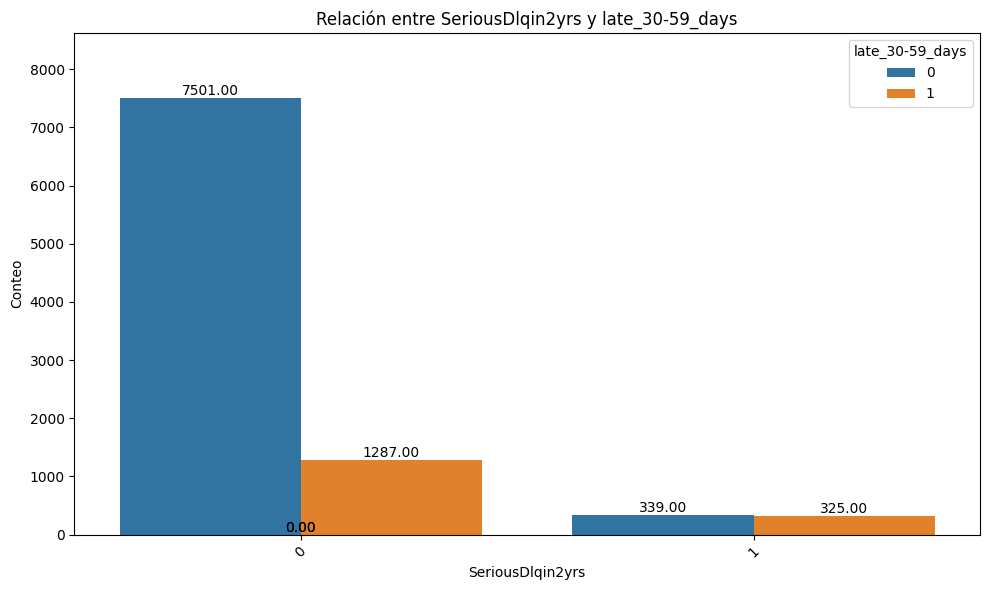

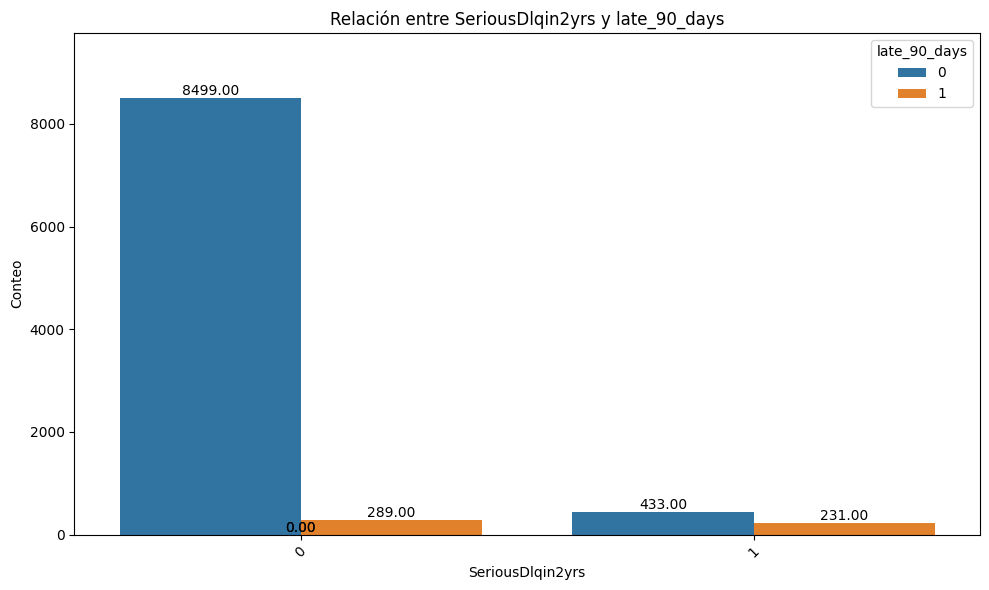

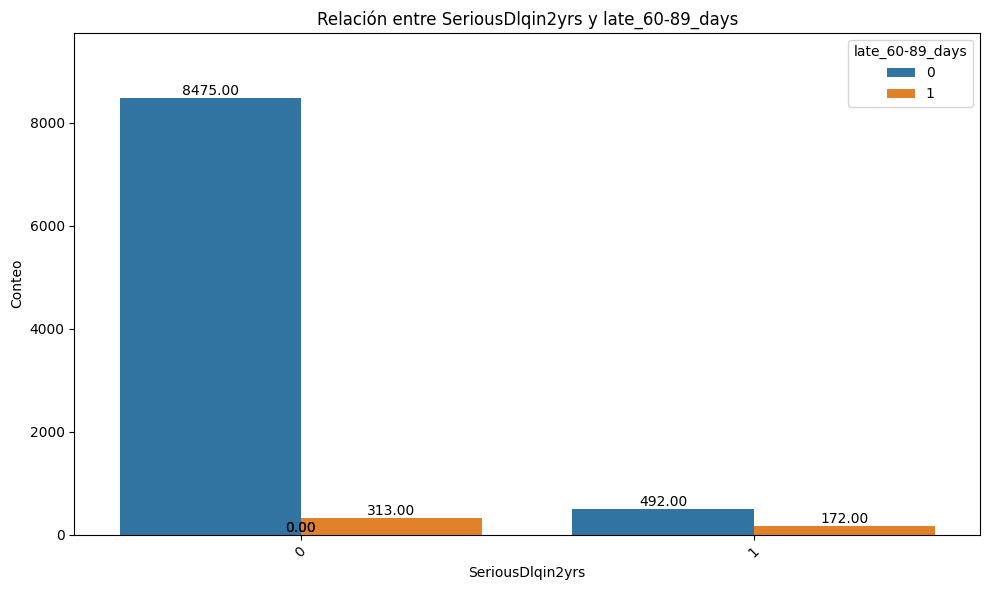

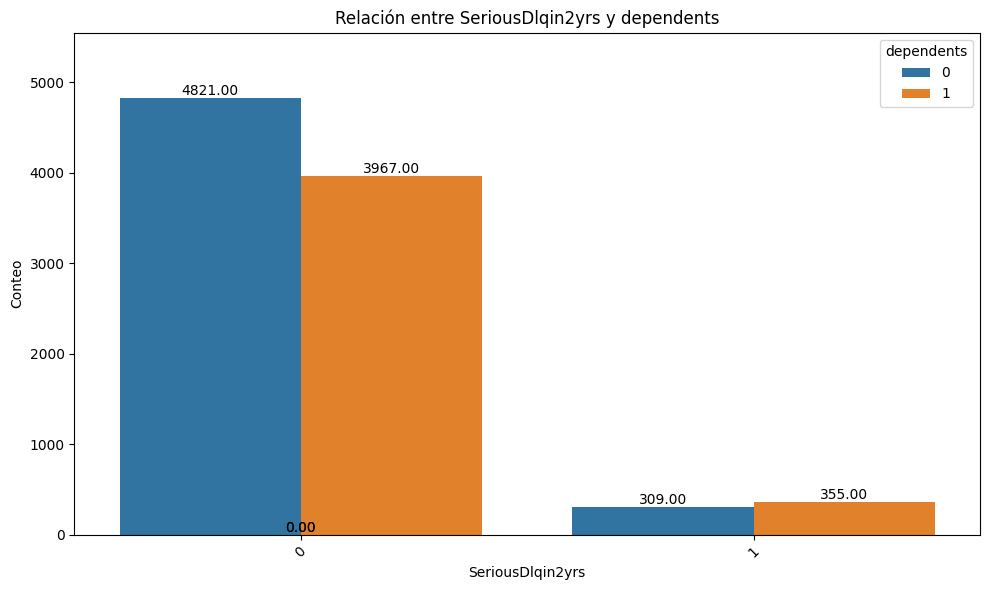

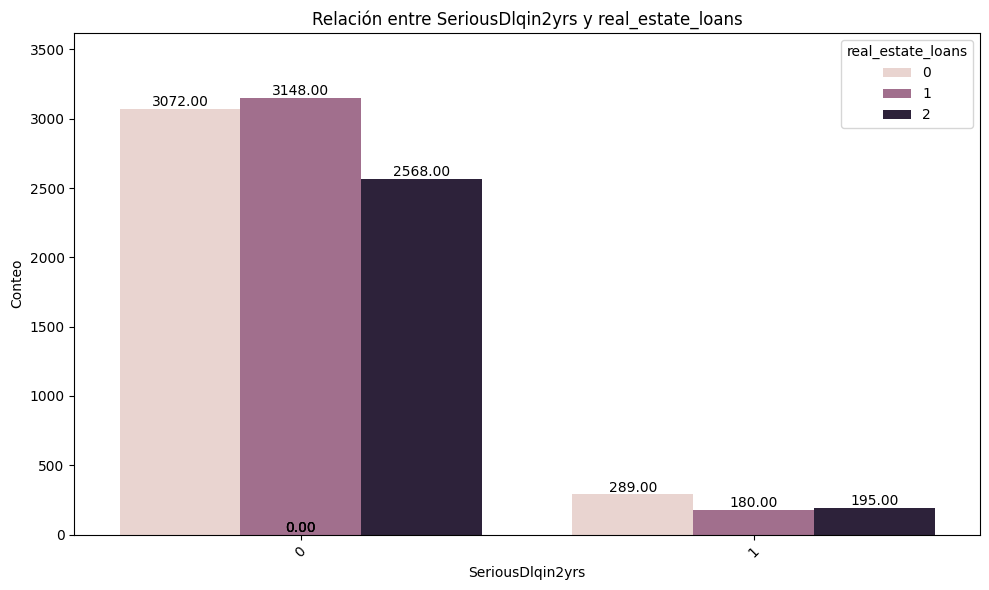

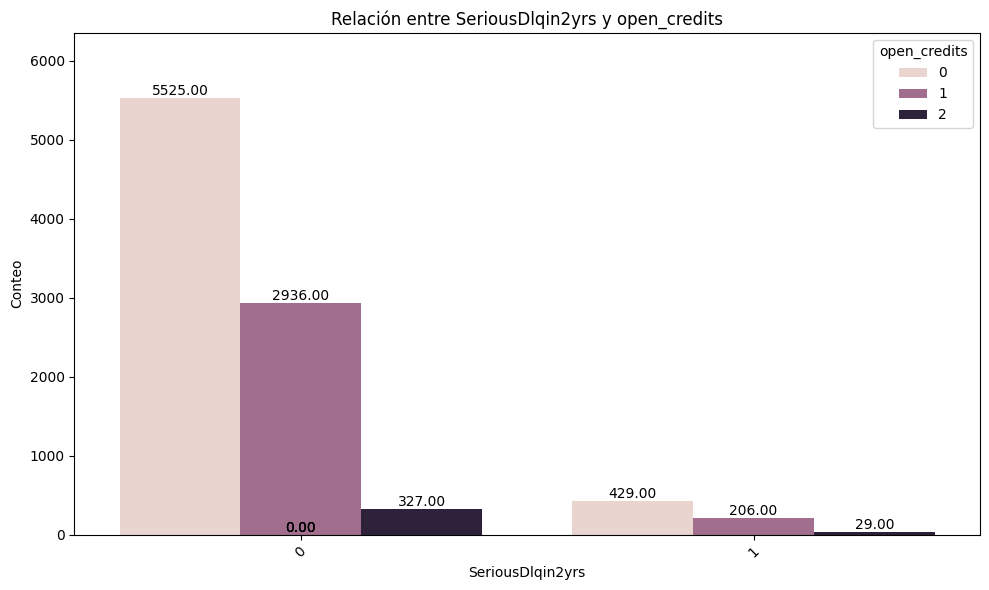

In [21]:
for col in cols_cat:
    bt.plot_categorical_relationship(train_analysis, target, col, show_values=True)

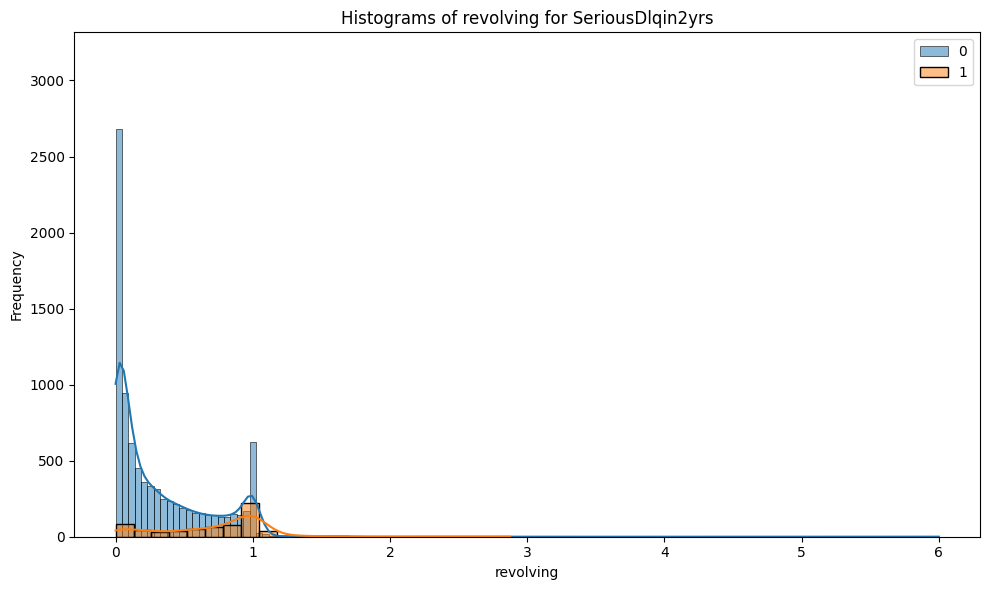

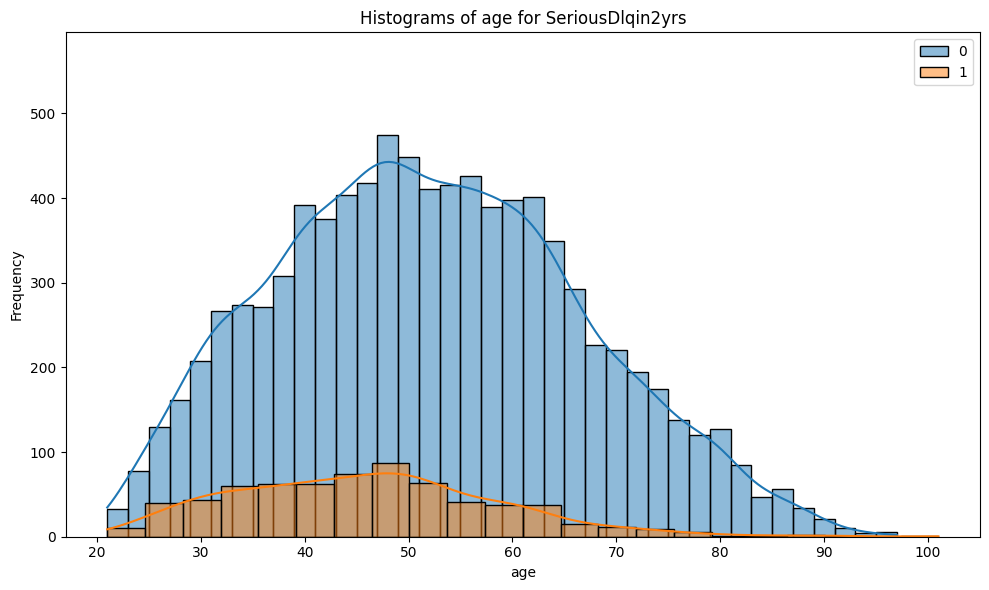

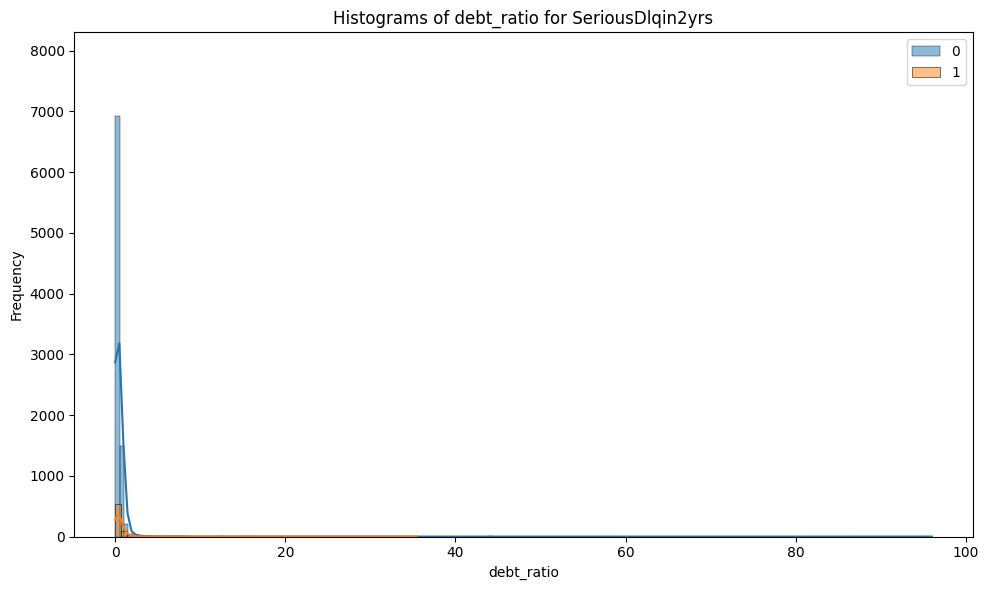

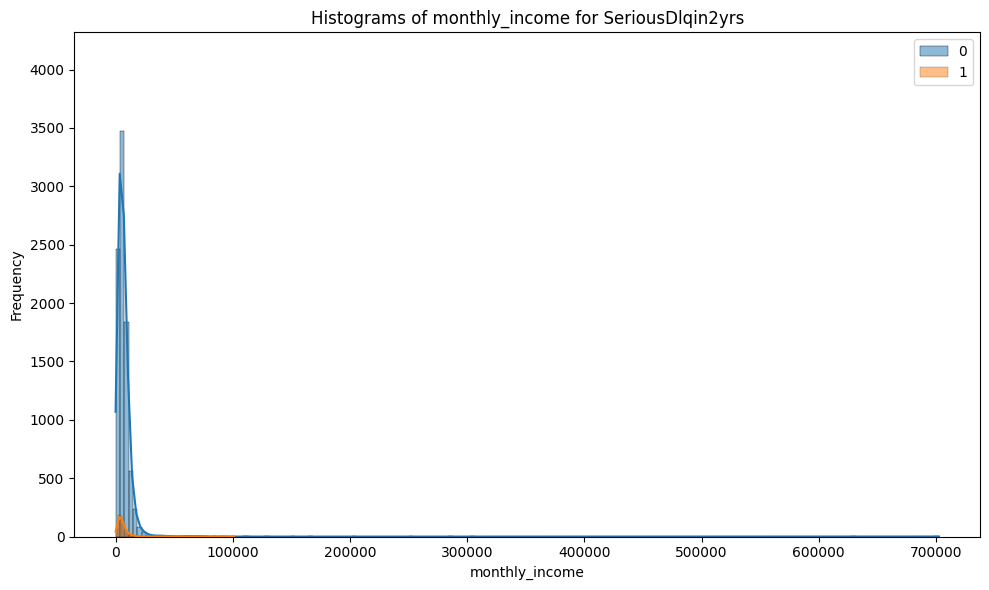

In [22]:
for col in cols_num:
    bt.plot_grouped_histograms(train_analysis, "SeriousDlqin2yrs", col)

<Axes: >

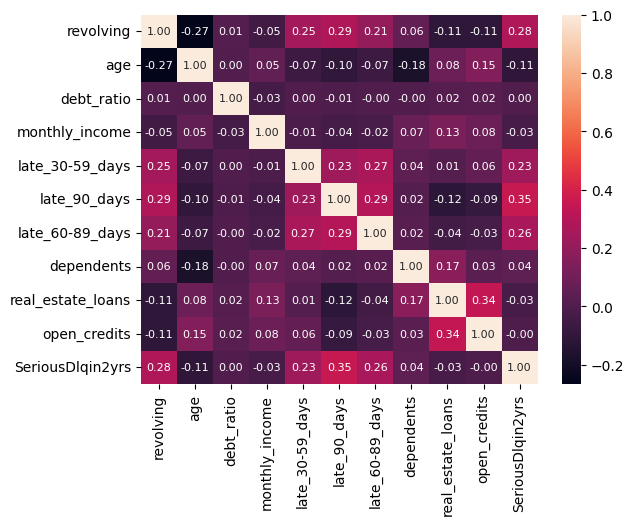

In [23]:
sns.heatmap(train_analysis.corr(numeric_only=True), annot_kws={"size": 8}, annot=True, fmt=".2f")

In [24]:
cols_num_w_target = [col for col in cols_num if col != target]
cols_num_w_target.append(target)

In [25]:
corr= train_analysis[cols_num_w_target].corr()
serie_corr = np.abs(corr[target])
serie_corr.sort_values(ascending = False)

SeriousDlqin2yrs    1.000000
revolving           0.277475
age                 0.105251
monthly_income      0.025449
debt_ratio          0.000089
Name: SeriousDlqin2yrs, dtype: float64

In [26]:
from sklearn.feature_selection import VarianceThreshold

umbral_varianza = 0.5

var_selector = VarianceThreshold(umbral_varianza)
var_selector.fit(X_train)
print("Lista seleccionada para selector de Varianza", var_selector.get_feature_names_out())

Lista seleccionada para selector de Varianza ['age' 'debt_ratio' 'monthly_income' 'real_estate_loans']


In [27]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=3)
x_data_kbest = selector.fit_transform(X_train[cols_num], y_train)
X_train_kbest = pd.DataFrame(x_data_kbest, columns = selector.get_feature_names_out())
X_train_kbest

,revolving,age,monthly_income
0,0.039187,61.0,3073.0
1,0.919317,41.0,3945.0
2,0.253718,49.0,13250.0
3,0.249462,26.0,764.0
4,0.224520,76.0,3150.0
...,...,...,...
9447,0.174437,61.0,7203.0
9448,0.039651,64.0,15667.0
9449,1.000000,29.0,2040.0
9450,0.945805,51.0,4500.0


In [44]:
from sklearn.metrics import mutual_info_score

feat_mis = []
for col in cols_cat:
    print(f"MI({col};{target}):", mutual_info_score(train_analysis[col],train_analysis[target]))
    if mutual_info_score(train_analysis[col],train_analysis[target]) > 0.01:
        feat_mis.append(col)
    

MI(late_30-59_days;SeriousDlqin2yrs): 0.020831100086090043
MI(late_90_days;SeriousDlqin2yrs): 0.03315981105348048
MI(late_60-89_days;SeriousDlqin2yrs): 0.019220687427717945
MI(dependents;SeriousDlqin2yrs): 0.0009074541147513493
MI(real_estate_loans;SeriousDlqin2yrs): 0.0013932461244414024
MI(open_credits;SeriousDlqin2yrs): 0.00010721216977072068


In [45]:
feat_skb = list(X_train_kbest.columns)
feat_skb_mis = feat_mis + feat_skb

In [46]:
feat_skb_mis

['late_30-59_days',
 'late_90_days',
 'late_60-89_days',
 'revolving',
 'age',
 'monthly_income']

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(random_state= 42)

In [30]:
rf_selector.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
from sklearn.feature_selection import SelectFromModel

selector_model = SelectFromModel(estimator=rf_selector, threshold="median")

In [32]:
selector_model.fit(X_train,y_train)

,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",RandomForestC...ndom_state=42)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",'median'
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1
,"max_features max_features: int, callable, default=NoneThe maximum number of features to select.- If an integer, then it specifies the maximum number of features to allow.- If a callable, then it specifies how to calculate the maximum number of features allowed. The callable will receive `X` as input: `max_features(X)`.- If `None`, then all features are kept.To only select based on ``max_features``, set ``threshold=-np.inf``... versionadded:: 0.20.. versionchanged:: 1.1 `max_features` accepts a callable.",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a ``coef_``attribute or ``feature_importances_`` attribute of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each o

In [48]:
feat_sfm = list(selector_model.get_feature_names_out())

In [49]:
feat_sfm

['revolving', 'age', 'debt_ratio', 'monthly_income', 'late_90_days']

In [34]:
from sklearn.feature_selection import RFE

In [35]:
rf_RFE = RandomForestClassifier(random_state= 42) # Puedes usar tu modelo, o modelos a probar o un modelo "proxy" como en la selección por modelo

rfe = RFE(estimator = rf_RFE,
          n_features_to_select= 5, # Iterará hasta quedarse con 5
          step = 1) # Elimina de una en una, pero es configurable

rfe.fit(X_train, y_train)
print(rfe.ranking_)
pd.DataFrame(rfe.ranking_, columns= ["ranking"], index = X_train.columns).sort_values("ranking")

[1 1 1 1 3 1 2 6 4 5]


,ranking
revolving,1
age,1
debt_ratio,1
monthly_income,1
late_90_days,1
late_60-89_days,2
late_30-59_days,3
real_estate_loans,4
open_credits,5
dependents,6


In [59]:
feat_rfe = ["revolving", "age", "debt_ratio", "monthly_income", "late_90_days"]

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

rf_SFS = RandomForestClassifier(random_state = 42)

sfs_forward = SequentialFeatureSelector(rf_SFS,
                                        n_features_to_select = 5,
                                        cv = 4,
                                        scoring = "balanced_accuracy")


sfs_forward.fit(X_train, y_train)


,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'balanced_accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [38]:
feat_sfs = list(sfs_forward.get_feature_names_out())

In [47]:
feat_sfs

['revolving', 'late_90_days', 'late_60-89_days', 'dependents', 'open_credits']

In [60]:
from collections import Counter

listas = [feat_skb_mis, feat_rfe, feat_sfs, feat_sfm]

votos = Counter()

for lista in listas:
    votos.update(lista)
    
print(votos)

feat_hv = []

for feat, vot in votos.items():
    if vot > 1:
        feat_hv.append(feat)

Counter({'late_90_days': 4, 'revolving': 4, 'age': 3, 'monthly_income': 3, 'late_60-89_days': 2, 'debt_ratio': 2, 'late_30-59_days': 1, 'dependents': 1, 'open_credits': 1})


In [61]:
feat_hv

['late_90_days',
 'late_60-89_days',
 'revolving',
 'age',
 'monthly_income',
 'debt_ratio']

In [73]:
lr = LogisticRegression(max_iter=1000,
                        random_state=42,
                        class_weight="balanced")

rf = RandomForestClassifier(random_state=42,
                            class_weight="balanced")

xgb = XGBClassifier(random_state=42)

In [57]:
listas.append(feat_hv)

In [62]:
X_train_skb_mis = X_train[feat_skb_mis]
X_train_rfe = X_train[feat_rfe]
X_train_sfs = X_train[feat_sfs]
X_train_sfm = X_train[feat_sfm]
X_train_hv = X_train[feat_hv]

In [79]:
scaler = StandardScaler()

In [80]:
trains_x = {
    "SKB+MI": X_train_skb_mis,
    "RFE": X_train_rfe,
    "SFS": X_train_sfs,
    "SFM": X_train_sfm,
    "HV": X_train_hv
}
from sklearn.pipeline import Pipeline

estimators = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42)
}

cv_scores = {}

for train_name, train_x in trains_x.items():
    for model_name, estimator in estimators.items():

        score = cross_val_score(
            estimator,
            train_x,
            y_train,
            cv=5,
            scoring="recall"
        )

        cv_scores[(train_name, model_name)] = float(score.mean())

In [81]:
cv_scores

{('SKB+MI', 'LR'): 0.710788334472545,
 ('SKB+MI', 'RF'): 0.2033037138300296,
 ('SKB+MI', 'XGB'): 0.21832991569833676,
 ('RFE', 'LR'): 0.7138072453861928,
 ('RFE', 'RF'): 0.17771701982228297,
 ('RFE', 'XGB'): 0.2002620186830713,
 ('SFS', 'LR'): 0.7273752563226247,
 ('SFS', 'RF'): 0.29216222374117107,
 ('SFS', 'XGB'): 0.21832991569833676,
 ('SFM', 'LR'): 0.7138072453861928,
 ('SFM', 'RF'): 0.17771701982228297,
 ('SFM', 'XGB'): 0.2002620186830713,
 ('HV', 'LR'): 0.7062884483937115,
 ('HV', 'RF'): 0.2003417634996582,
 ('HV', 'XGB'): 0.22286397812713604}

In [82]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

lr_grid = LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
)

grid = GridSearchCV(
    estimator=lr_grid,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sfs, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
0.7273752563226247


c:\Users\salit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\salit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.